## Imports

In [26]:
import mesmer
import model
import model_analysis
import Play

import importlib
import matplotlib.pyplot as plt
import xarray as xr
import xskillscore as xs
import numpy as np

import cartopy.crs as ccrs

from PIL import Image



### Updates (temp)

In [2]:
importlib.reload(model.stats);
importlib.reload(model.shape_data);
importlib.reload(model.transform);



## Load Data

In [3]:
is_local_data = True
month_idx = 4
safe = False

In [4]:
mrsol = model.shape_data.load_data_set(var = "mrsol", local = is_local_data, run_idx=1)

In [5]:
mrsol_pruned_ds = model.shape_data.prune_group_ds_timespan(mrsol,Month_idx=month_idx)


In [6]:
tas_ds = model.shape_data.load_data_set(var = "tas", local = is_local_data, run_idx=1)
pr_ds = model.shape_data.load_data_set(var = "pr", local = is_local_data, run_idx=1)
tas_ds = model.shape_data.prune_group_ds_timespan(tas_ds,Month_idx=month_idx)
pr_ds = model.shape_data.prune_group_ds_timespan(pr_ds,Month_idx=month_idx)

input_ds = xr.merge([tas_ds,pr_ds]).drop_vars("file_qf")




### Mask and Stack Data

In [7]:
mrsol_masked_ds, chunk_mask, detail_mask_mean = model.mask.mask_nonpositiv_height_chunks(mrsol_pruned_ds.drop_vars("depth_bnds"))
input_masked_ds = model.mask.mask_mask(input_ds,chunk_mask)


In [8]:
mrsol_stack = mesmer.grid.stack_lat_lon(mrsol_masked_ds)

input_stack = mesmer.grid.stack_lat_lon(input_masked_ds)


### Quantiles

In [9]:
mrsol_stack = mrsol_stack.transpose("gridcell","depth","time")
input_stack = input_stack.transpose("gridcell","time")


In [10]:
num_quantiles = 7
quantiles = np.linspace(0, 1, num_quantiles + 1)


In [11]:
tas_edges = input_stack["tas"].quantile(
    quantiles,
    dim="time",
    skipna=True,
)
pr_edges = input_stack["pr"].quantile(
    quantiles,
    dim="time",
    skipna=True,
)

In [12]:
import xskillscore as xs

obs = xr.DataArray(np.array([0,1]), dims = ["events"],coords={"events": np.arange(0,2)})
fcst = xr.DataArray(np.array([[0,0],[1,2]]), dims = ["events","bin_member"],coords={"events": np.arange(0,2),"bin_member":np.arange(0,2)})
    

crps = xs.crps_ensemble(
    observations=obs,      # z.B. dim: ("member",)
    forecasts=fcst,        # z.B. dim: ("member", "ensemble")
    dim = [],
    member_dim="bin_member"
)

print(crps)

<xarray.DataArray (events: 2)> Size: 16B
array([0.  , 0.25])
Coordinates:
  * events   (events) int64 16B 0 1


In [13]:
def local_score(data,mask,old_scores,old_binsize):
    #print(gridcell)
    n_samples = mask.sum()
    new_binsize = old_binsize.copy()
    new_binsize[mask] = n_samples
    if n_samples == 0:
        return old_scores, new_binsize
    
    new_scores = old_scores.copy()

    #print(data[:,mask])
    for d in range(0,len(data)):
        targets = xr.DataArray(np.array(data[d,mask]), dims = ["events"],coords={"events": np.arange(0,n_samples)})
        #print(targets)
        bins = xr.DataArray(np.array([data[d,mask]]*n_samples), dims = ["events","bin_member"],coords={"events": np.arange(0,n_samples)})
        #print(bins)
        #print("done")

        #print(n_samples)
        #print(xs.crps_ensemble(targets,bins,member_dim="bin_member"))
        score = xs.crps_ensemble(targets,bins,dim=[],member_dim="bin_member")
        #print(score)
        #print(old_scores)
        #print(old_scores.shape)
        #print(mask.shape)
        #print("lul")
        new_scores[d,mask] = score.values
    return new_scores, new_binsize

In [14]:
"""
fig, axes = plt.subplots(
        num_quantiles,
        num_quantiles,
        figsize=(12, 12),
        sharex=True,
        sharey=True

    )
"""
#mrsol_bins = xr.full_like(mrsol_stack.expand_dims(bin_member=np.arange(mrsol_stack.sizes["time"])), np.nan)
mrsol_stack = mrsol_stack.isel(depth=slice(0,3))
crps_scores = xr.full_like(mrsol_stack,0).rename({"mrsol":"crps_score"})
tas_idx_mat = xr.full_like(mrsol_stack.mean("depth"),0).rename({"mrsol":"tas_idx"})
pr_idx_mat = xr.full_like(mrsol_stack.mean("depth"),0).rename({"mrsol":"pr_idx"})
bin_sizes = xr.full_like(mrsol_stack.mean("depth"),0).rename({"mrsol":"bin_size"})



for tas_idx in range(num_quantiles):
    for pr_idx in range(num_quantiles):
        mask = (
                (input_stack["tas"] >= tas_edges[tas_idx]) &
                (input_stack["tas"] < tas_edges[tas_idx+1]) &
                (input_stack["pr"] >= pr_edges[pr_idx]) &
                (input_stack["pr"] < pr_edges[pr_idx+1])
            )
  
        new_scores, new_binsize = xr.apply_ufunc(local_score,mrsol_stack["mrsol"].where(mask),mask,crps_scores["crps_score"],bin_sizes["bin_size"],input_core_dims=[["depth","time"], ["time"],["depth","time"],["time"]], output_core_dims=[["depth","time"],["time"]], vectorize = True)
        print()
        crps_scores["crps_score"] = xr.where(mask,new_scores,crps_scores["crps_score"]) 

        bin_sizes["bin_size"] = xr.where(mask,new_binsize,bin_sizes["bin_size"])

        tas_idx_mat["tas_idx"] = xr.where(mask,tas_idx,tas_idx_mat["tas_idx"])
        
        pr_idx_mat["pr_idx"] = xr.where(mask,pr_idx,pr_idx_mat["pr_idx"])
        
    

        """
        for g in range(mrsol_stack.sizes["gridcell"]):
            for t in range(mrsol_stack.sizes["time"]):

                values = mrsol_stack["mrsol"][:, g].values[
                    mask[:, t, g]
                ]

                mrsol_bins["mrsol"][0:len(values), t, g] = values
        """
        #mrsol_bins = mrsol_stack.mrsol.where(mask)
        """
        bin_quantiles = xr_quantile_beta.mrsol.where(mask).values.flatten()
        bin_quantiles = bin_quantiles[np.isfinite(bin_quantiles)]
        axes[num_quantiles-tas_idx-1,pr_idx].hist(bin_quantiles.reshape(-1), bins = 100)
        """
        


#xr_quantile_beta
#quantile_beta
#bin_quantiles
#mrsol_stack.sizes["time"]
#mrsol_bins
#crps_scores.isel(depth=0).crps_score.plot()
bin_predictor = xr.merge([crps_scores,tas_idx_mat,pr_idx_mat,bin_sizes])

In [15]:
bin_predictor

<xarray.Dataset> Size: 3MB
Dimensions:     (gridcell: 378, time: 165, depth: 3)
Coordinates:
    lat         (gridcell) float64 3kB -51.75 -47.25 -42.75 ... 78.75 78.75
    lon         (gridcell) float64 3kB 288.0 288.0 288.0 ... 270.0 279.0 297.0
  * time        (time) datetime64[ns] 1kB 1850-04-30 1851-04-30 ... 2014-04-30
  * depth       (depth) float64 24B 0.03 0.19 0.78
    height      float64 8B 2.0
Dimensions without coordinates: gridcell
Data variables:
    crps_score  (gridcell, time, depth) float64 1MB 0.0512 0.2458 ... 0.0002885
    tas_idx     (gridcell, time) float64 499kB 2.0 3.0 2.0 1.0 ... 5.0 5.0 1.0
    pr_idx      (gridcell, time) float64 499kB 1.0 4.0 0.0 0.0 ... 4.0 3.0 4.0
    bin_size    (gridcell, time) float64 499kB 5.0 5.0 3.0 5.0 ... 6.0 3.0 4.0
Attributes: (12/52)
    CDI:                       Climate Data Interface version 1.9.6 (http://m...
    history:                   Wed Jul 15 10:14:02 2026: cdo remapbil,r40x40 ...
    source:                    MPI-ESM1.2-LR (2017): \naerosol: none, prescri...
    institution:               Max Planck Institute for Meteorology
    Conventions:               CF-1.7 CMIP-6.2
    activity_id:               CMIP
    ...                        ...
    cmor_version:              3.5.0
    tracking_id:               hdl:21.14100/0fd5d006-722a-4650-a835-398b6aae92c9
    cmip6-ng:                  \ncontact = cmip6-archive@env.ethz.ch\ndescrip...
    original_file_names:       /net/atmos/data/cmip6/historical/Emon/mrsol/MP...
    original_file_hash_codes:  35dde960416cda436bd90358a67f602de138e51219997c...
    CDO:                       Climate Data Operators version 1.9.6 (http://m...

In [88]:
pr_edges

<xarray.DataArray 'pr' (quantile: 8, gridcell: 378)> Size: 24kB
array([[2.03511941e-05, 8.67399391e-06, 1.04828484e-05, ...,
        7.75417051e-07, 2.03838108e-07, 6.87291181e-08],
       [3.56136899e-05, 4.11498983e-05, 3.77938963e-05, ...,
        2.14563383e-06, 1.58535981e-06, 1.77208193e-06],
       [4.03996009e-05, 4.90599731e-05, 4.65862102e-05, ...,
        3.13337479e-06, 2.46413766e-06, 2.65222540e-06],
       ...,
       [5.26142145e-05, 6.63635077e-05, 7.10131852e-05, ...,
        6.25479138e-06, 5.39987254e-06, 6.62017913e-06],
       [5.78115022e-05, 7.45107597e-05, 8.74417904e-05, ...,
        7.59856162e-06, 6.85451198e-06, 8.51860182e-06],
       [7.50959473e-05, 9.71254480e-05, 1.30858327e-04, ...,
        1.50499498e-05, 1.53399889e-05, 2.49992253e-05]], shape=(8, 378))
Coordinates:
  * quantile  (quantile) float64 64B 0.0 0.1429 0.2857 ... 0.7143 0.8571 1.0
    lat       (gridcell) float64 3kB -51.75 -47.25 -42.75 ... 78.75 78.75 78.75
    lon       (gridcell) float64 3kB 288.0 288.0 288.0 ... 270.0 279.0 297.0
Dimensions without coordinates: gridcell
Attributes:
    standard_name:  precipitation_flux
    long_name:      Precipitation
    units:          kg m-2 s-1
    comment:        includes both liquid and solid phases
    original_name:  pr
    cell_methods:   area: time: mean
    cell_measures:  area: areacella

In [87]:
bin_predictor

<xarray.Dataset> Size: 3MB
Dimensions:     (gridcell: 378, time: 165, depth: 3)
Coordinates:
    lat         (gridcell) float64 3kB -51.75 -47.25 -42.75 ... 78.75 78.75
    lon         (gridcell) float64 3kB 288.0 288.0 288.0 ... 270.0 279.0 297.0
  * time        (time) datetime64[ns] 1kB 1850-04-30 1851-04-30 ... 2014-04-30
  * depth       (depth) float64 24B 0.03 0.19 0.78
    height      float64 8B 2.0
Dimensions without coordinates: gridcell
Data variables:
    crps_score  (gridcell, time, depth) float64 1MB 0.0512 0.2458 ... 0.0002885
    tas_idx     (gridcell, time) float64 499kB 2.0 3.0 2.0 1.0 ... 5.0 5.0 1.0
    pr_idx      (gridcell, time) float64 499kB 1.0 4.0 0.0 0.0 ... 4.0 3.0 4.0
    bin_size    (gridcell, time) float64 499kB 5.0 5.0 3.0 5.0 ... 6.0 3.0 4.0
Attributes: (12/52)
    CDI:                       Climate Data Interface version 1.9.6 (http://m...
    history:                   Wed Jul 15 10:14:02 2026: cdo remapbil,r40x40 ...
    source:                    MPI-ESM1.2-LR (2017): \naerosol: none, prescri...
    institution:               Max Planck Institute for Meteorology
    Conventions:               CF-1.7 CMIP-6.2
    activity_id:               CMIP
    ...                        ...
    cmor_version:              3.5.0
    tracking_id:               hdl:21.14100/0fd5d006-722a-4650-a835-398b6aae92c9
    cmip6-ng:                  \ncontact = cmip6-archive@env.ethz.ch\ndescrip...
    original_file_names:       /net/atmos/data/cmip6/historical/Emon/mrsol/MP...
    original_file_hash_codes:  35dde960416cda436bd90358a67f602de138e51219997c...
    CDO:                       Climate Data Operators version 1.9.6 (http://m...

In [ ]:
bin_predictor_unstacked = mesmer.grid.unstack_lat_lon_and_align(bin_predictor,mrsol_pruned_ds.isel(depth=slice(0,3)))

In [17]:
bin_predictor_unstacked

<xarray.Dataset> Size: 13MB
Dimensions:     (time: 165, depth: 3, lat: 40, lon: 40)
Coordinates:
  * time        (time) datetime64[ns] 1kB 1850-04-30 1851-04-30 ... 2014-04-30
  * depth       (depth) float64 24B 0.03 0.19 0.78
  * lat         (lat) float64 320B -87.75 -83.25 -78.75 ... 78.75 83.25 87.75
  * lon         (lon) float64 320B 0.0 9.0 18.0 27.0 ... 324.0 333.0 342.0 351.0
    height      float64 8B 2.0
Data variables:
    crps_score  (time, depth, lat, lon) float64 6MB nan nan nan ... nan nan nan
    tas_idx     (time, lat, lon) float64 2MB nan nan nan nan ... nan nan nan nan
    pr_idx      (time, lat, lon) float64 2MB nan nan nan nan ... nan nan nan nan
    bin_size    (time, lat, lon) float64 2MB nan nan nan nan ... nan nan nan nan
Attributes: (12/52)
    CDI:                       Climate Data Interface version 1.9.6 (http://m...
    history:                   Wed Jul 15 10:14:02 2026: cdo remapbil,r40x40 ...
    source:                    MPI-ESM1.2-LR (2017): \naerosol: none, prescri...
    institution:               Max Planck Institute for Meteorology
    Conventions:               CF-1.7 CMIP-6.2
    activity_id:               CMIP
    ...                        ...
    cmor_version:              3.5.0
    tracking_id:               hdl:21.14100/0fd5d006-722a-4650-a835-398b6aae92c9
    cmip6-ng:                  \ncontact = cmip6-archive@env.ethz.ch\ndescrip...
    original_file_names:       /net/atmos/data/cmip6/historical/Emon/mrsol/MP...
    original_file_hash_codes:  35dde960416cda436bd90358a67f602de138e51219997c...
    CDO:                       Climate Data Operators version 1.9.6 (http://m...

17


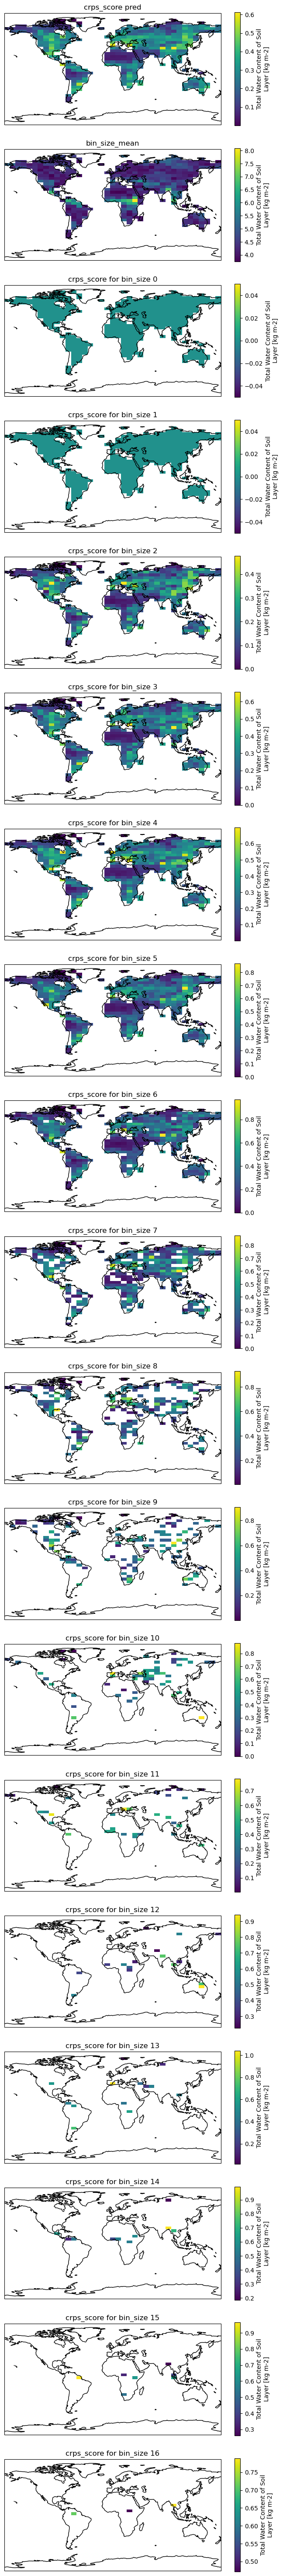

In [18]:
max_bin = int(np.nanmax(bin_predictor_unstacked.bin_size.values))
print(max_bin)

fig_global_crpss, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    nrows=max_bin+2,
    ncols=1,
    figsize=(8, max_bin * 4 + 8)
)
depth = 0

da = bin_predictor_unstacked.isel(depth=depth).mean("time").crps_score
da.plot(ax=ax[0])
ax[0].coastlines()
ax[0].set_title("crps_score pred")

da = bin_predictor_unstacked.isel(depth=depth).mean("time").bin_size
da.plot(ax=ax[1])
ax[1].coastlines()
ax[1].set_title("bin_size_mean")

for s in range(0,max_bin):
    da = xr.where((bin_predictor_unstacked.isel(depth=depth).bin_size == s), bin_predictor_unstacked.isel(depth=depth).crps_score, np.nan).mean("time")
    da.plot(ax=ax[s+2])
    ax[s+2].coastlines()
    ax[s+2].set_title(f"crps_score for bin_size {s}")



In [19]:
PIF = model.shape_data.load_plot(var= "mrsol", scen = "historical", folder = "MPI-ESM1-2-LR/Beta_dist", name = f"fig_global_crpss_clipped_month_idx = {month_idx}_approx_mon_emp11")

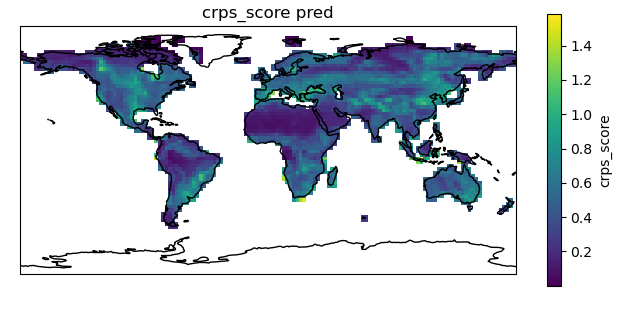

In [20]:
beta_PIF = PIF.crop((80, 130, 700, 440))
beta_PIF

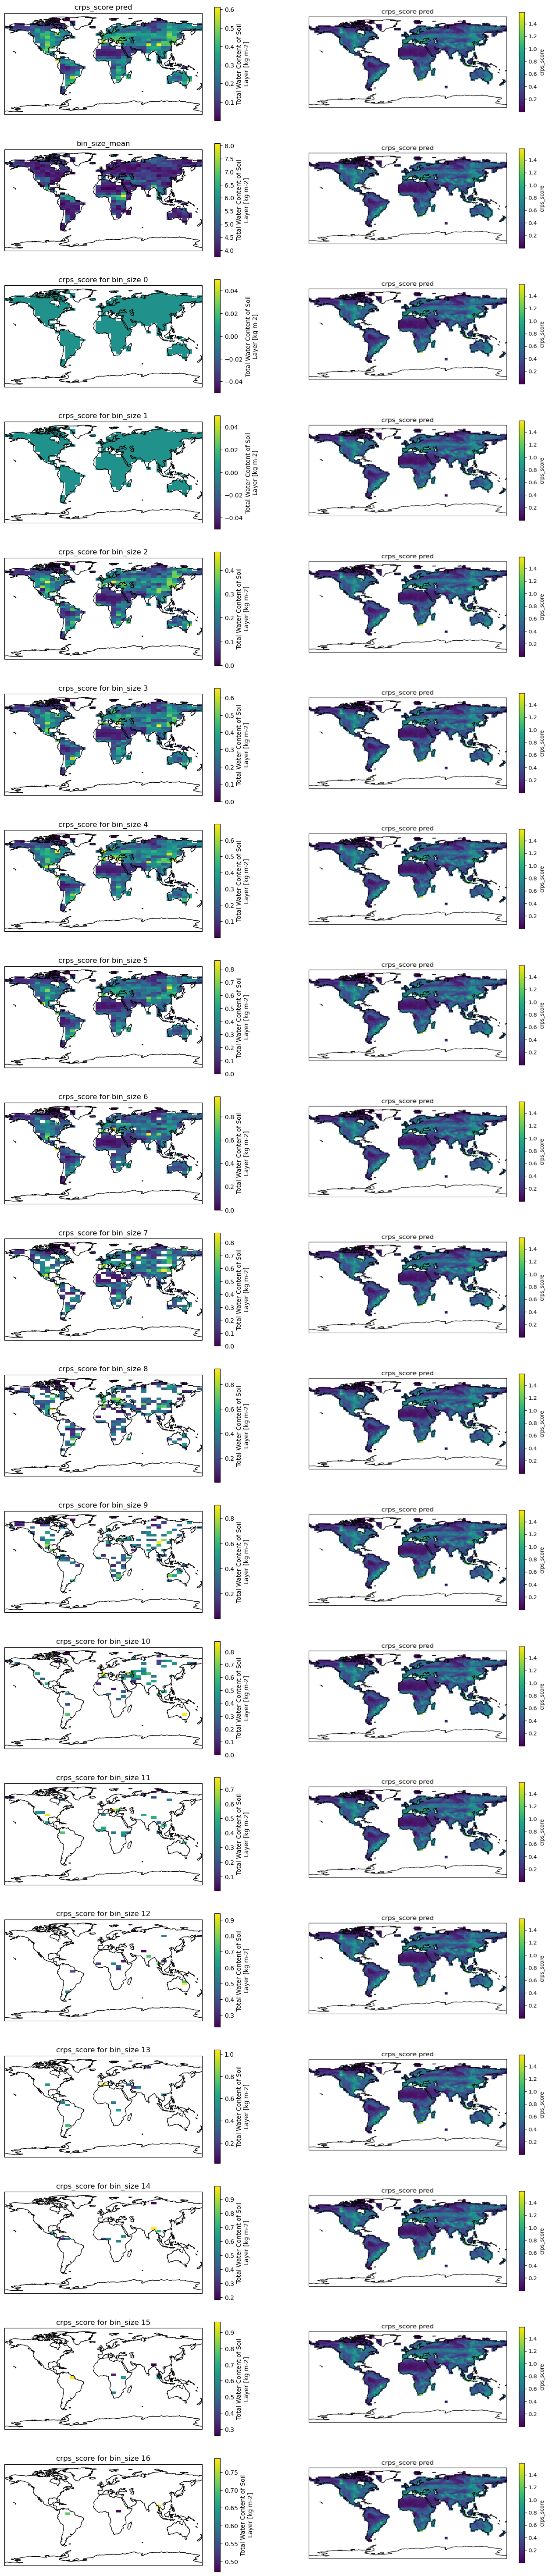

In [22]:
max_bin = int(np.nanmax(bin_predictor_unstacked.bin_size.values))
#print(max_bin)
fig = plt.figure(figsize=(16, max_bin * 4 + 8))

ax = np.empty((max_bin+2, 2), dtype=object)

for p in range(max_bin+2):
    ax[p,0] = fig.add_subplot(max_bin+2, 2, 2*p+1,
                              projection=ccrs.PlateCarree())
    ax[p,1] = fig.add_subplot(max_bin+2, 2, 2*p+2)


depth = 0

da = bin_predictor_unstacked.isel(depth=depth).mean("time").crps_score
da.plot(ax=ax[0,0])
ax[0,0].coastlines()
ax[0,0].set_title("crps_score pred")

da = bin_predictor_unstacked.isel(depth=depth).mean("time").bin_size
da.plot(ax=ax[1,0])
ax[1,0].coastlines()
ax[1,0].set_title("bin_size_mean")

for s in range(0,max_bin):
    da = xr.where((bin_predictor_unstacked.isel(depth=depth).bin_size == s), bin_predictor_unstacked.isel(depth=depth).crps_score, np.nan).mean("time")
    da.plot(ax=ax[s+2,0])
    ax[s+2,0].coastlines()
    ax[s+2,0].set_title(f"crps_score for bin_size {s}")

img = np.array(beta_PIF)
for p in range(0,max_bin+2):
    ax[p,1].clear()
    ax[p,1].imshow(img, aspect = "auto")
    #ax[p, 1].set_xlim(0, img.shape[1])
    #ax[p, 1].set_ylim(img.shape[0], 0)
    ax[p,1].axis("off")
    #print(p, ax[p,1].images)


In [ ]:
#model.save.save_plot(fig, var= "mrsol", scen = "historical", folder = "MPI-ESM1-2-LR/Beta_dist", name = f"empirisches_limit_7x7_bin_size_crps_against_global_beta_approx_mon_emp11_crps_clipped_month_idx = {month_idx}")

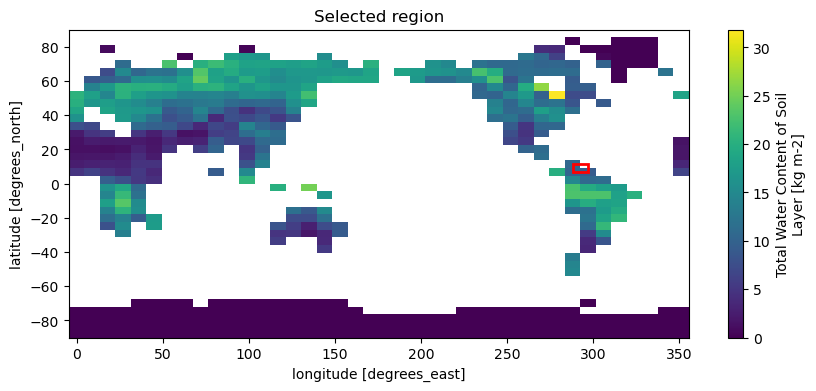

In [54]:
Play.plot_one_var.show_my_position(lat_idx=21, lon_idx=32)

In [98]:
lat = bin_predictor_unstacked.lat[21]
lon = bin_predictor_unstacked.lon[32]

In [100]:

local_bin_predictor = bin_predictor_unstacked.sel(lat= lat, lon =lon).isel(depth = 0)
local_mrsol = mrsol_masked_ds.sel(lat= lat, lon =lon).isel(depth = 0)
local_tas_edges = mesmer.grid.unstack_lat_lon(tas_edges).sel(lat= lat, lon =lon)
local_pr_edges = mesmer.grid.unstack_lat_lon(pr_edges).sel(lat= lat, lon =lon)

In [101]:
local_bin_predictor

<xarray.Dataset> Size: 7kB
Dimensions:     (time: 165)
Coordinates:
  * time        (time) datetime64[ns] 1kB 1850-04-30 1851-04-30 ... 2014-04-30
    height      float64 8B 2.0
    lon         float64 8B 288.0
    lat         float64 8B 6.75
    depth       float64 8B 0.03
Data variables:
    crps_score  (time) float64 1kB 0.1258 0.182 0.06807 ... 0.0 0.3048 0.4757
    tas_idx     (time) float64 1kB 0.0 4.0 1.0 6.0 0.0 ... 4.0 5.0 6.0 6.0 3.0
    pr_idx      (time) float64 1kB 5.0 1.0 5.0 1.0 0.0 ... 5.0 3.0 4.0 0.0 4.0
    bin_size    (time) float64 1kB 5.0 7.0 5.0 6.0 0.0 ... 5.0 2.0 1.0 13.0 5.0
Attributes: (12/52)
    CDI:                       Climate Data Interface version 1.9.6 (http://m...
    history:                   Wed Jul 15 10:14:02 2026: cdo remapbil,r40x40 ...
    source:                    MPI-ESM1.2-LR (2017): \naerosol: none, prescri...
    institution:               Max Planck Institute for Meteorology
    Conventions:               CF-1.7 CMIP-6.2
    activity_id:               CMIP
    ...                        ...
    cmor_version:              3.5.0
    tracking_id:               hdl:21.14100/0fd5d006-722a-4650-a835-398b6aae92c9
    cmip6-ng:                  \ncontact = cmip6-archive@env.ethz.ch\ndescrip...
    original_file_names:       /net/atmos/data/cmip6/historical/Emon/mrsol/MP...
    original_file_hash_codes:  35dde960416cda436bd90358a67f602de138e51219997c...
    CDO:                       Climate Data Operators version 1.9.6 (http://m...

In [102]:
local_mrsol

<xarray.Dataset> Size: 3kB
Dimensions:  (time: 165)
Coordinates:
  * time     (time) datetime64[ns] 1kB 1850-04-30 1851-04-30 ... 2014-04-30
    lon      float64 8B 288.0
    lat      float64 8B 6.75
    depth    float64 8B 0.03
    height   float64 8B 2.0
Data variables:
    mrsol    (time) float64 1kB 14.19 12.05 13.74 11.43 ... 13.03 10.36 13.45
Attributes: (12/52)
    CDI:                       Climate Data Interface version 1.9.6 (http://m...
    history:                   Wed Jul 15 10:14:02 2026: cdo remapbil,r40x40 ...
    source:                    MPI-ESM1.2-LR (2017): \naerosol: none, prescri...
    institution:               Max Planck Institute for Meteorology
    Conventions:               CF-1.7 CMIP-6.2
    activity_id:               CMIP
    ...                        ...
    cmor_version:              3.5.0
    tracking_id:               hdl:21.14100/0fd5d006-722a-4650-a835-398b6aae92c9
    cmip6-ng:                  \ncontact = cmip6-archive@env.ethz.ch\ndescrip...
    original_file_names:       /net/atmos/data/cmip6/historical/Emon/mrsol/MP...
    original_file_hash_codes:  35dde960416cda436bd90358a67f602de138e51219997c...
    CDO:                       Climate Data Operators version 1.9.6 (http://m...

In [103]:
local_pr_edges

<xarray.DataArray 'pr' (quantile: 8)> Size: 64B
array([1.33626681e-05, 4.32672583e-05, 4.99499331e-05, 5.81755828e-05,
       6.37099346e-05, 6.92675547e-05, 7.95015594e-05, 1.08463082e-04])
Coordinates:
  * quantile  (quantile) float64 64B 0.0 0.1429 0.2857 ... 0.7143 0.8571 1.0
    lat       float64 8B 6.75
    lon       float64 8B 288.0
    height    float64 8B 2.0
Attributes:
    standard_name:  precipitation_flux
    long_name:      Precipitation
    units:          kg m-2 s-1
    comment:        includes both liquid and solid phases
    original_name:  pr
    cell_methods:   area: time: mean
    cell_measures:  area: areacella

In [66]:
num_quantiles

7

In [ ]:
local_tas_edges =

/home/pjunghans/miniconda3/envs/mesmer-tests/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/pjunghans/miniconda3/envs/mesmer-tests/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


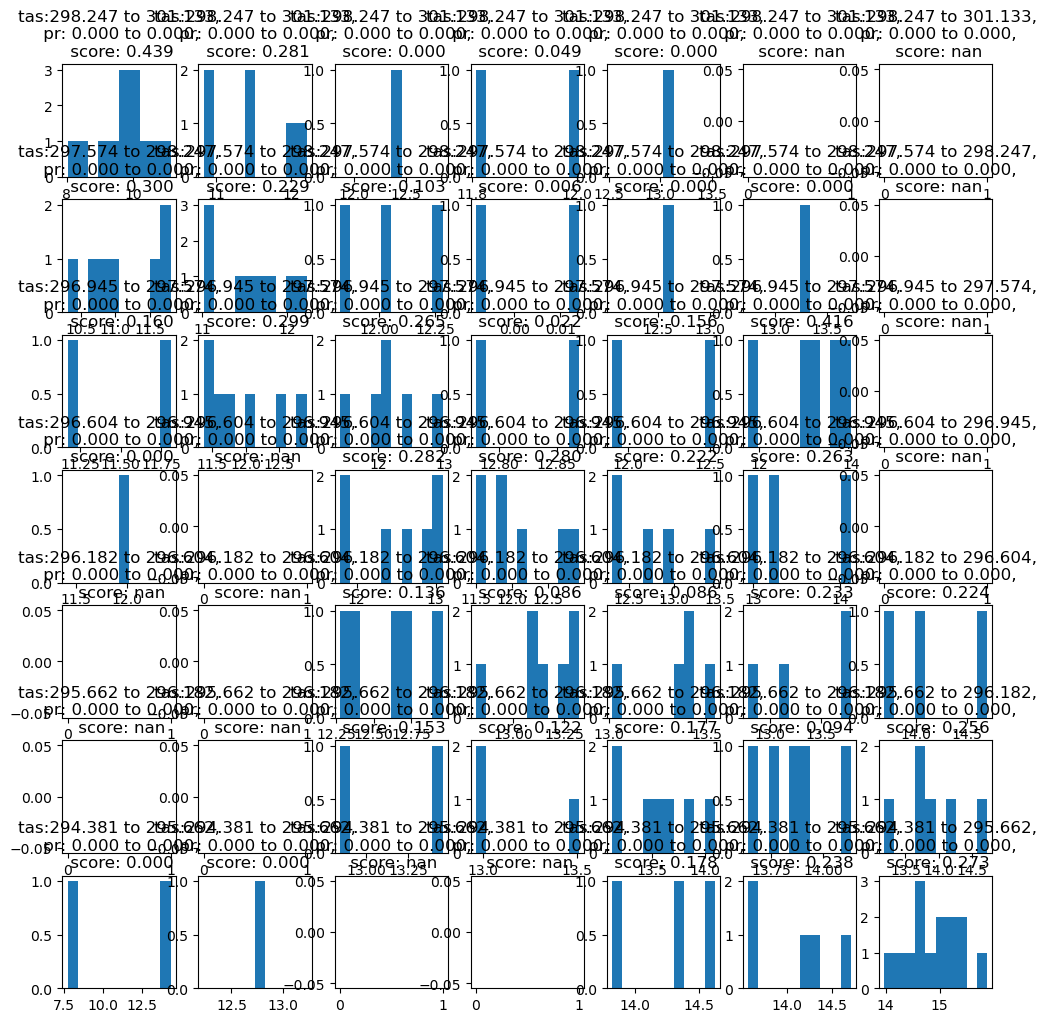

In [106]:
fig_split, axes = plt.subplots(
        num_quantiles,
        num_quantiles,
        figsize=(12, 12),
        sharex=False,
        sharey=False

    )


for tas_idx in range(num_quantiles):
    for pr_idx in range(num_quantiles):
        mask = np.array((local_bin_predictor.tas_idx.values == tas_idx) & (local_bin_predictor.pr_idx.values == pr_idx))
        data = local_mrsol.mrsol.values[mask]
        score = np.mean(local_bin_predictor.crps_score.values[mask])

        axes[num_quantiles-tas_idx-1,pr_idx].hist(data)
        axes[num_quantiles-tas_idx-1,pr_idx].set_title(f"tas:{local_tas_edges[tas_idx]:.3f} to {local_tas_edges[tas_idx+1]:.3f},\n pr: {local_pr_edges[pr_idx]:.3f} to {local_pr_edges[pr_idx + 1]:.3f},\n score: {score:.3f}")



In [64]:
max_tas_idx

<xarray.DataArray 'tas_idx' ()> Size: 8B
array(6.)
Coordinates:
    height   float64 8B 2.0
    lon      float64 8B 288.0
    lat      float64 8B 6.75
    depth    float64 8B 0.03

In [24]:
#crps_scores["crps_score"].where(mask)#,crps_scores["gridcell"],mask

In [23]:
#(crps_scores.crps_score.max("time")-crps_scores.crps_score.min("time")).plot()